# Monte Carlo & numerical methods

When a problem has no closed-form answer — a path-dependent option, a portfolio
VaR, a model with no analytic likelihood — we compute it **numerically**. This
notebook covers the three workhorses: **Monte Carlo** simulation, **root
finding**, and **finite differences**.

The Monte Carlo idea is simple and universal: to find an expectation
$\mathbb E[g(X)]$, draw many samples and average. The catch is the
**$1/\sqrt N$ convergence** — to halve the error you need *four times* the
samples — which motivates **variance-reduction** tricks.

**Roadmap**

1. Monte Carlo integration and the $1/\sqrt N$ law
2. Pricing an option by simulation — and checking it against Black–Scholes
3. Variance reduction with antithetic variates
4. Root finding — backing out **implied volatility**
5. Finite differences — Greeks by bump-and-reprice


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize
from scipy.stats import norm

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
rng = np.random.default_rng(0)


## 1. Monte Carlo integration and the $1/\sqrt N$ law

Estimate $\pi$ by throwing darts at a unit square: the fraction landing inside
the quarter-circle is $\pi/4$. The estimate's error shrinks like $1/\sqrt N$ —
on a log–log plot of error vs sample size, the slope is $-\tfrac12$. This rate
is *dimension-independent*, which is why Monte Carlo beats grid methods for
high-dimensional finance problems (baskets, path-dependence).


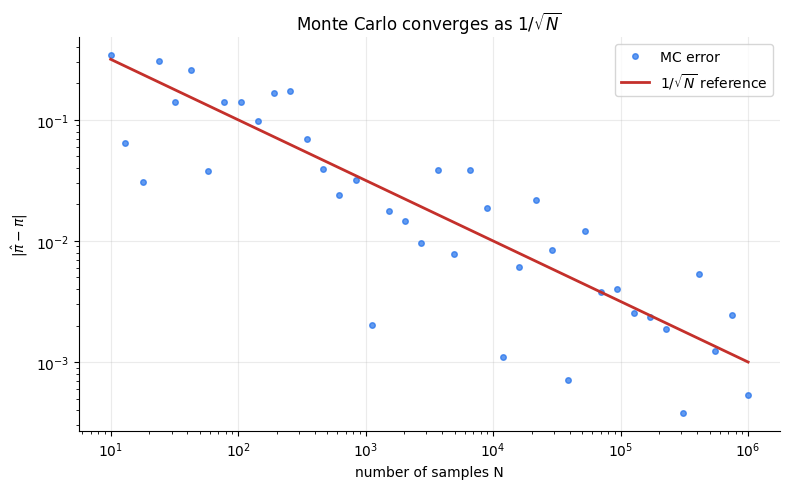

estimate with N=10^6: pi ~ 3.1392


In [2]:
Ns = np.logspace(1, 6, 40).astype(int)
errors = []
for N in Ns:
    pts = rng.random((N, 2))
    inside = np.mean(np.sum(pts**2, axis=1) <= 1.0) * 4.0
    errors.append(abs(inside - np.pi))
errors = np.array(errors)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(Ns, errors, 'o', color='#1f6feb', ms=4, alpha=0.7, label='MC error')
ax.loglog(Ns, 1.0 / np.sqrt(Ns), color='#c4302b', lw=2, label=r'$1/\sqrt{N}$ reference')
ax.set_xlabel('number of samples N'); ax.set_ylabel(r'$|\hat\pi - \pi|$')
ax.set_title('Monte Carlo converges as $1/\\sqrt{N}$'); ax.legend()
plt.tight_layout(); plt.show()
print(f'estimate with N=10^6: pi ~ {np.mean(np.sum(rng.random((1_000_000,2))**2,axis=1)<=1)*4:.4f}')


## 2. Pricing an option by simulation

Under the risk-neutral measure a stock follows GBM with drift $r$ (notebook 08),
so the terminal price is $S_T = S_0\exp[(r-\tfrac12\sigma^2)T + \sigma\sqrt T Z]$.
A European call is worth the discounted expected payoff
$e^{-rT}\,\mathbb E[\max(S_T-K,0)]$ — which we estimate by averaging over
simulated $S_T$. The **Black–Scholes** formula gives the exact answer to check
against.


In [3]:
def bs_call(S, K, T, r, sigma):
    """Black-Scholes European call price (and delta)."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return price, norm.cdf(d1)        # price, delta

def mc_call(S, K, T, r, sigma, N, seed=0, antithetic=False):
    r_ = np.random.default_rng(seed)
    if antithetic:
        z = r_.standard_normal(N // 2)
        z = np.concatenate([z, -z])           # mirrored draws
    else:
        z = r_.standard_normal(N)
    ST = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z)
    payoff = np.maximum(ST - K, 0.0)
    disc = np.exp(-r * T) * payoff
    return disc.mean(), disc.std(ddof=1) / np.sqrt(N)    # price, std error

S, K, T, r, sigma = 100.0, 105.0, 1.0, 0.03, 0.20
bs_price, bs_delta = bs_call(S, K, T, r, sigma)
mc_price, mc_se = mc_call(S, K, T, r, sigma, N=200_000, seed=1)
print(f'Black-Scholes call price = {bs_price:.4f}')
print(f'Monte Carlo  (N=200k)    = {mc_price:.4f} +/- {1.96*mc_se:.4f} (95% CI)')
print(f'difference               = {abs(mc_price - bs_price):.4f}  '
      f'(within CI: {abs(mc_price-bs_price) < 1.96*mc_se})')


Black-Scholes call price = 7.1281
Monte Carlo  (N=200k)    = 7.0806 +/- 0.0548 (95% CI)
difference               = 0.0475  (within CI: True)


## 3. Variance reduction — antithetic variates

The same accuracy from fewer samples saves real compute. **Antithetic variates**
pair each draw $Z$ with its mirror $-Z$: the payoffs are negatively correlated, so
their average has lower variance. For the same $N$ the standard error drops — a
free lunch from a one-line change.


price estimator std over 200 runs (lower = more efficient):
  plain      = 0.0401
  antithetic = 0.0374   (7% reduction)


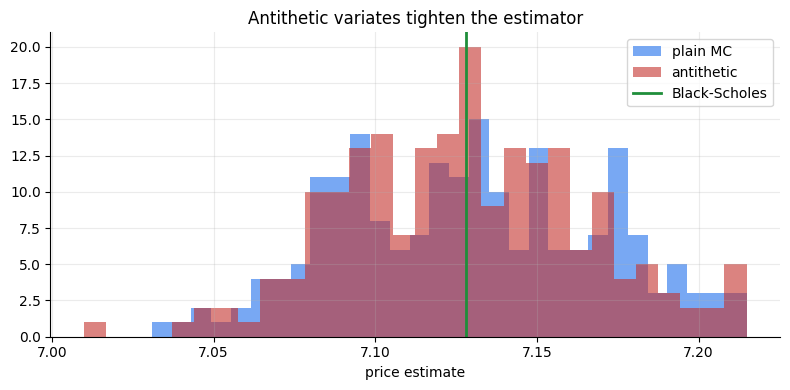

In [4]:
N = 100_000
plain = [mc_call(S, K, T, r, sigma, N, seed=s)[0] for s in range(200)]
anti = [mc_call(S, K, T, r, sigma, N, seed=s, antithetic=True)[0] for s in range(200)]
print(f'price estimator std over 200 runs (lower = more efficient):')
print(f'  plain      = {np.std(plain):.4f}')
print(f'  antithetic = {np.std(anti):.4f}   '
      f'({1 - np.std(anti)/np.std(plain):.0%} reduction)')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(plain, bins=30, alpha=0.6, color='#1f6feb', label='plain MC')
ax.hist(anti, bins=30, alpha=0.6, color='#c4302b', label='antithetic')
ax.axvline(bs_price, color='#1f8e3a', lw=2, label='Black-Scholes')
ax.set_title('Antithetic variates tighten the estimator'); ax.set_xlabel('price estimate')
ax.legend()
plt.tight_layout(); plt.show()


## 4. Root finding — implied volatility

Quoted option prices don't come with a volatility attached; the market quotes a
*price*, and we invert Black–Scholes to find the $\sigma$ that reproduces it —
the **implied volatility**. Since the call price is strictly increasing in
$\sigma$, this is a 1-D root-find (notebook 07), solved robustly with bracketing.


priced at sigma=0.27 -> price 9.9183 -> recovered IV 0.2700


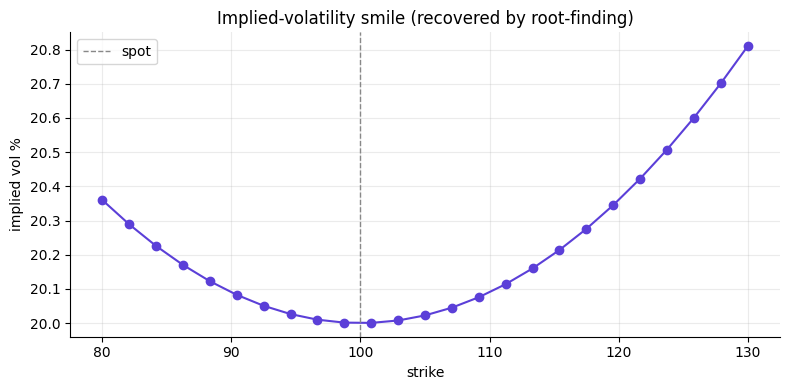

In [5]:
def implied_vol(market_price, S, K, T, r):
    obj = lambda sig: bs_call(S, K, T, r, sig)[0] - market_price
    return optimize.brentq(obj, 1e-6, 5.0)

# Round-trip check: price at a known sigma, then recover it.
true_sigma = 0.27
mkt = bs_call(S, K, T, r, true_sigma)[0]
iv = implied_vol(mkt, S, K, T, r)
print(f'priced at sigma={true_sigma:.2f} -> price {mkt:.4f} -> recovered IV {iv:.4f}')

# The IV 'smile': real markets imply higher vol for OTM strikes (fat tails).
strikes = np.linspace(80, 130, 25)
smile = 0.20 + 0.0009 * (strikes - 100) ** 2 / 100   # synthetic convex smile
prices = [bs_call(S, k, T, r, s_)[0] for k, s_ in zip(strikes, smile)]
ivs = [implied_vol(p, S, k, T, r) for p, k in zip(prices, strikes)]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(strikes, np.array(ivs) * 100, 'o-', color='#5b3fd8')
ax.axvline(S, color='#888', ls='--', lw=1, label='spot')
ax.set_title('Implied-volatility smile (recovered by root-finding)')
ax.set_xlabel('strike'); ax.set_ylabel('implied vol %'); ax.legend()
plt.tight_layout(); plt.show()


## 5. Finite differences — Greeks by bump-and-reprice

A **Greek** is a sensitivity — the derivative of price with respect to an input.
When no formula is handy, approximate it by **bumping** the input and repricing:
the central difference $\,[f(S+h)-f(S-h)]/2h\,$ is accurate to $O(h^2)$. We check
the finite-difference **delta** against the analytic $N(d_1)$.


In [6]:
h = 0.5
price_up = bs_call(S + h, K, T, r, sigma)[0]
price_dn = bs_call(S - h, K, T, r, sigma)[0]
fd_delta = (price_up - price_dn) / (2 * h)
fd_gamma = (price_up - 2 * bs_call(S, K, T, r, sigma)[0] + price_dn) / h**2
print(f'delta:  finite-difference = {fd_delta:.5f}   analytic N(d1) = {bs_delta:.5f}')
print(f'gamma:  finite-difference = {fd_gamma:.5f}   '
      f'analytic = {norm.pdf((np.log(S/K)+(r+0.5*sigma**2)*T)/(sigma*np.sqrt(T)))/(S*sigma*np.sqrt(T)):.5f}')
print('\nThe same bump-and-reprice trick gives Greeks for ANY pricer, '
      'including the Monte Carlo one above.')


delta:  finite-difference = 0.50240   analytic N(d1) = 0.50241
gamma:  finite-difference = 0.01995   analytic = 0.01995

The same bump-and-reprice trick gives Greeks for ANY pricer, including the Monte Carlo one above.


## What next?

* **Options Greeks (notebook 25)** and **options pricing (26)** build out the full
  Greek surface and pricing stack that this notebook previews.
* **Gamma exposure (27)** aggregates dealer Greeks into market-structure levels.
* **Risk:** the same simulation engine produces **Monte Carlo VaR/CVaR** for a
  portfolio — simulate the P&L distribution and read off the tail.
* **Model calibration** is root-finding/optimization (notebook 07) applied to
  match a model's outputs to market quotes — implied vol is the simplest case.
